### 1 Loading Dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("bartender_tips.csv")
df.head()

,Customers,Hours_Worked,Drinks_Sold,Day_Type,Tips
0,71,4,142,Weekend,106.56
1,34,7,68,Weekday,37.81
2,91,5,273,Weekend,140.73
3,80,4,160,Weekday,96.53
4,40,10,120,Weekday,42.33


### 2. Exploring the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Customers     100 non-null    int64  
 1   Hours_Worked  100 non-null    int64  
 2   Drinks_Sold   100 non-null    int64  
 3   Day_Type      100 non-null    object 
 4   Tips          100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


In [4]:
df.describe()

,Customers,Hours_Worked,Drinks_Sold,Tips
count,100.000000,100.000000,100.000000,100.000000
mean,58.110000,7.200000,177.350000,84.891700
std,24.295693,2.044949,93.557671,32.392639
min,20.000000,4.000000,42.000000,26.820000
25%,34.000000,6.000000,98.750000,56.760000
50%,60.000000,7.000000,159.500000,85.395000
75%,79.000000,9.000000,249.750000,109.775000
max,99.000000,10.000000,376.000000,148.560000


In [5]:
df.isnull().sum()

Customers       0
Hours_Worked    0
Drinks_Sold     0
Day_Type        0
Tips            0
dtype: int64

### 3. Visualize Data

In [6]:
import matplotlib.pyplot as plt

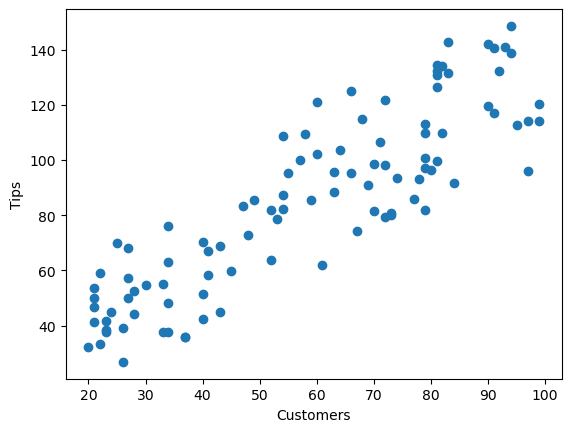

In [7]:
plt.xlabel("Customers")
plt.ylabel("Tips")
plt.scatter(
    df["Customers"],
    df["Tips"]
)

### 4. Label Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Day_Type"] = le.fit_transform(df["Day_Type"])
df["Day_Type"] # WEEKDAY: 0, WEEKEND: 1

0     1
1     0
2     1
3     0
4     0
     ..
95    1
96    1
97    1
98    1
99    0
Name: Day_Type, Length: 100, dtype: int32

### 5. Defining Features & Targets

In [9]:
X = df[
    [
        "Customers",
        "Hours_Worked",
        "Drinks_Sold",
        "Day_Type"
    ]
]

y = df["Tips"]

### 6. Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# display(X_train)
# display(X_test)
# display(y_train)
# display(y_test)

### 7. Training The Model

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

### 8. Prediction

In [12]:
predictions = model.predict(X_test)

predictions[:5]

array([48.13774995, 97.89278451, 73.88768391, 31.36910266, 63.59189213])

### 9. Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# MAE = average error in £
mae = mean_absolute_error(
    y_test,
    predictions
)

# r2 (R Square) determines how well the model explains tips
r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("R²:", r2)

MAE: 5.864942768473904
R²: 0.9418384767786656


### 10. Predicting A New Shift

In [14]:
new_shift = pd.DataFrame({
    "Customers": [75],
    "Hours_Worked": [8],
    "Drinks_Sold": [220],
    "Day_Type": [1]
})

prediction = model.predict(new_shift)

print(prediction)

[114.91501485]


### 11. Final Visualizations

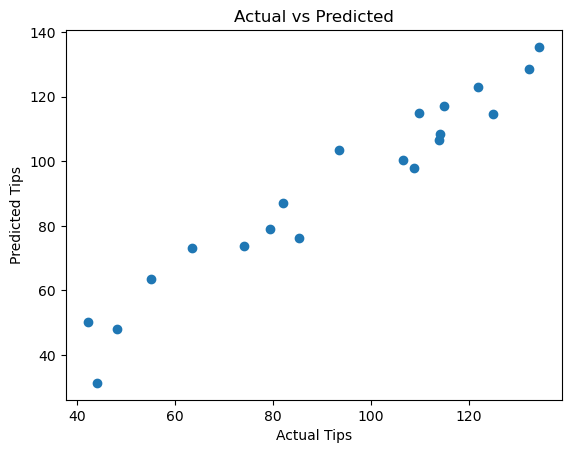

In [15]:
plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")

plt.title("Actual vs Predicted")

plt.show()